## Importing Libraries 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading Dataset

In [2]:
df = pd.read_csv(r"D:\My Course Ai Bin\Machine Learning\Linear\advertising (1).csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


## EDA

In [3]:
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [4]:
df.shape

(200, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()  

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [8]:
df.columns  

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

## Correlation Heatmap

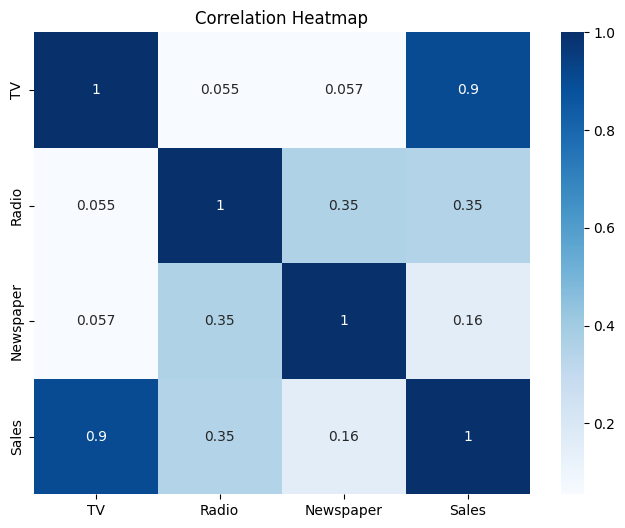

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

## TV Advertising vs Sales

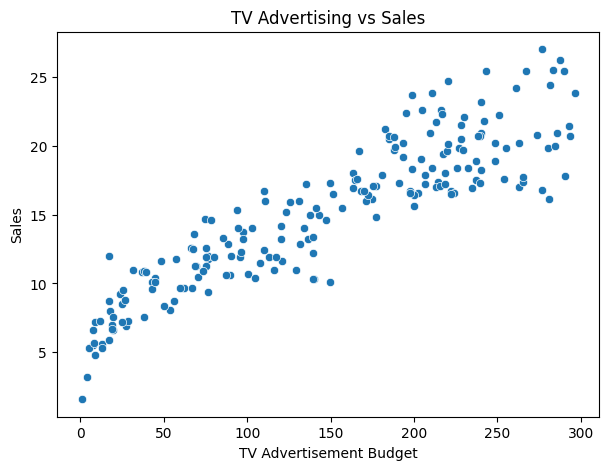

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['TV'], y=df['Sales'])
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertisement Budget")
plt.ylabel("Sales")
plt.show()

## Radio Advertising Distribution

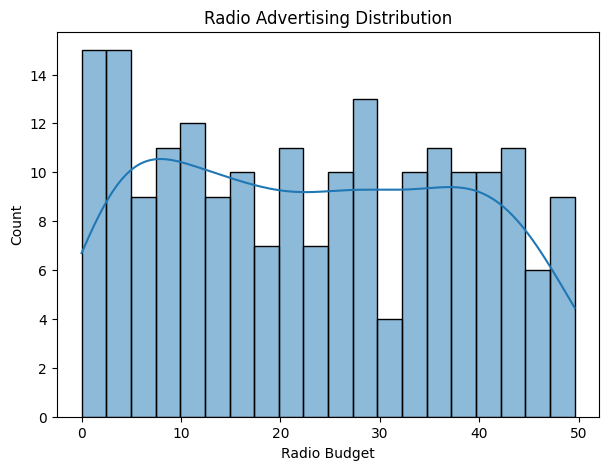

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Radio'], bins=20, kde=True)
plt.title("Radio Advertising Distribution")
plt.xlabel("Radio Budget")
plt.show()

## Select Features and Target

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

## Splitting Dataset 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 3)
Testing Data Shape: (40, 3)


## Train Linear Regression Model

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


## Model Prediction 

In [ ]:
y_pred = model.predict(X_test)
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results.head()

,Actual,Predicted
95,16.9,17.034772
15,22.4,20.409740
30,21.4,23.723989
158,7.3,9.272785
128,24.7,21.682719


## Evaluating Model 

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.2748262109549338
Mean Squared Error: 2.9077569102710896
R2 Score: 0.9059011844150826


## Actual vs Predicted Values 

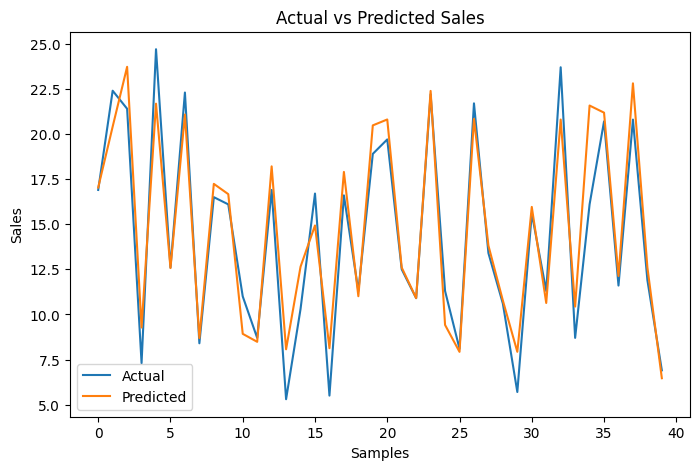

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("Actual vs Predicted Sales")
plt.xlabel("Samples")
plt.ylabel("Sales")
plt.legend()
plt.show()

## Feature Coefficient 

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coefficients

,Feature,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337
